<a href="https://colab.research.google.com/github/lukalklikadze/walmart-sales-forecasting/blob/main/notebooks/xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ══ Bootstrap ══
!pip -q install mlflow kaggle xgboost

!git clone -q https://github.com/lukalklikadze/walmart-sales-forecasting.git /content/repo \
    2>/dev/null || (cd /content/repo && git pull -q)
import sys; sys.path.append("/content/repo")

from src.config import setup_env, DATA_DIR, KAGGLE_COMP
print("MLflow →", setup_env())

import os, glob, zipfile, subprocess
os.makedirs(DATA_DIR, exist_ok=True)
subprocess.run(["kaggle","competitions","download","-c",KAGGLE_COMP,"-p",DATA_DIR,"--force"], check=True)
with zipfile.ZipFile(os.path.join(DATA_DIR, KAGGLE_COMP + ".zip")) as z: z.extractall(DATA_DIR)
for inner in glob.glob(os.path.join(DATA_DIR, "*.csv.zip")):
    with zipfile.ZipFile(inner) as z: z.extractall(DATA_DIR)

from src.data import load_raw
train, test, stores, features = load_raw()
print("train:", train.shape, "| test:", test.shape)

MLflow → https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow
train: (421570, 16) | test: (115064, 15)


# XGBoost

Tree model on the shared feature stack (calendar features + lags). The plan for this notebook:

1. First run uses the lag setup from our original plan (lags 1, 2, 52 + rolling stats) as a
   baseline. We already expect it to fail: the test set is 39 weeks into the future, so lag_1
   and lag_2 simply don't exist there - but during training the model happily relies on them.
2. Second run uses only long lags (52, 53, 104), which always reach back into known history.
3. Then we try predicting log1p of sales instead of raw sales (a signed version, because
   ~1300 rows are negative due to returns).
4. Small manual parameter sweep.
5. The best config gets refit on the full training data and saved as a pipeline that runs
   directly on the raw test set.

Validation is the last 39 weeks of train, the metric is WMAE (holiday weeks count 5x).
XGBoost handles the NaN lags on its own, so no imputation needed.

In [3]:
import time
import numpy as np, pandas as pd
import mlflow, mlflow.sklearn
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

from src.features import (CalendarFeatures, LagFeatures, DropColumns,
                          LAG_CONFIG_BASELINE, LAG_CONFIG_SUBMISSION)
from src.train_val_split import time_based_split
from src.metrics import wmae

# last 39 weeks of train as validation - same length as the real test horizon
VAL_WEEKS = 39
tr, va = time_based_split(train, val_weeks=VAL_WEEKS)
Xtr, ytr = tr.drop(columns=["Weekly_Sales"]), tr["Weekly_Sales"]
Xva, yva = va.drop(columns=["Weekly_Sales"]), va["Weekly_Sales"]
X_full, y_full = train.drop(columns=["Weekly_Sales"]), train["Weekly_Sales"]
print(f"train fold {tr.Date.min().date()}..{tr.Date.max().date()} ({len(tr):,} rows)")
print(f"val fold   {va.Date.min().date()}..{va.Date.max().date()} "
      f"({len(va):,} rows, {int(va.IsHoliday.sum()):,} holiday rows)")

train fold 2010-02-05..2012-01-27 (305,982 rows)
val fold   2012-02-03..2012-10-26 (115,588 rows, 5,967 holiday rows)


In [4]:
XGB_DEFAULTS = dict(n_estimators=600, learning_rate=0.05, max_depth=8,
                    subsample=0.9, colsample_bytree=0.9,
                    tree_method="hist", n_jobs=-1, random_state=42)

# log1p that also works for the negative (returns) rows
def signed_log1p(y):
    return np.sign(y) * np.log1p(np.abs(y))

def signed_expm1(z):
    return np.sign(z) * np.expm1(np.abs(z))

def build_pipeline(lag_cfg, log_target=False, **xgb_overrides):
    model = xgb.XGBRegressor(**{**XGB_DEFAULTS, **xgb_overrides})
    if log_target:
        model = TransformedTargetRegressor(regressor=model,
                                           func=signed_log1p, inverse_func=signed_expm1)
    return Pipeline([
        ("calendar", CalendarFeatures()),
        ("lags",     LagFeatures(**lag_cfg)),
        ("drop",     DropColumns()),
        ("model",    model),
    ])

RESULTS = {}   # run_name -> (val_wmae, config to rebuild the pipeline)

def run_experiment(run_name, lag_cfg, log_target=False, **xgb_overrides):
    with mlflow.start_run(run_name=run_name):
        pipe = build_pipeline(lag_cfg, log_target, **xgb_overrides)
        t0 = time.time(); pipe.fit(Xtr, ytr)
        score = wmae(yva, pipe.predict(Xva), Xva["IsHoliday"])
        mlflow.log_params({"lags": str(lag_cfg["lags"]), "windows": str(lag_cfg["windows"]),
                           "log_target": log_target, "val_weeks": VAL_WEEKS,
                           **{**XGB_DEFAULTS, **xgb_overrides}})
        mlflow.log_metrics({"val_wmae": score, "fit_seconds": time.time() - t0})
        RESULTS[run_name] = (score, dict(lag_cfg=lag_cfg, log_target=log_target,
                                         overrides=xgb_overrides))
        print(f"{run_name:36s} val WMAE {score:9.1f}")
        return score

mlflow.set_experiment("XGBoost_Training")

2026/07/09 09:12:26 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/3925448f6c4d49ed81fd26e8e65fbcc5', creation_time=1783588346520, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1783588346520, lifecycle_stage='active', name='XGBoost_Training', tags={}, trace_location=None, workspace='default'>

In [5]:
# run 1: the naive lag config. expected to be bad (lag_1/lag_2 don't exist at
# test time), but we log it anyway - the gap to the next run is the point
run_experiment("baseline_lags", LAG_CONFIG_BASELINE)

baseline_lags                        val WMAE    8711.5
🏃 View run baseline_lags at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2/runs/69c253a3b1ff434b845af7293489fcce
🧪 View experiment at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2


8711.526977235997

In [6]:
# run 2: long lags only, these exist for the whole 39-week horizon
run_experiment("submission_lags", LAG_CONFIG_SUBMISSION)

submission_lags                      val WMAE    1811.1
🏃 View run submission_lags at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2/runs/c32f8ad6d1dc4c32b617e2440b6b763e
🧪 View experiment at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2


1811.0849751800606

In [7]:
# run 3: same features, but predict signed log1p of sales
run_experiment("submission_lags_log1p", LAG_CONFIG_SUBMISSION, log_target=True)

submission_lags_log1p                val WMAE    1781.9
🏃 View run submission_lags_log1p at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2/runs/8d8eb5f87fa64910b974a99d62575068
🧪 View experiment at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2


1781.883435738524

In [8]:
# small manual sweep, using whichever target version won above
use_log = RESULTS["submission_lags_log1p"][0] < RESULTS["submission_lags"][0]
print("tuning with log_target =", use_log)
grid = [
    dict(max_depth=6),
    dict(max_depth=10),
    dict(n_estimators=1200, learning_rate=0.03),
    dict(min_child_weight=5, subsample=0.8),
]
for g in grid:
    name = "tuned_" + "_".join(f"{k}{v}" for k, v in g.items())
    run_experiment(name, LAG_CONFIG_SUBMISSION, log_target=use_log, **g)

tuning with log_target = True
tuned_max_depth6                     val WMAE    1815.8
🏃 View run tuned_max_depth6 at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2/runs/6388f7fb6101408985dbcaf13316a3e2
🧪 View experiment at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2
tuned_max_depth10                    val WMAE    1796.1
🏃 View run tuned_max_depth10 at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2/runs/0f935092a7454af496ca231d8ea72157
🧪 View experiment at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2
tuned_n_estimators1200_learning_rate0.03 val WMAE    1776.6
🏃 View run tuned_n_estimators1200_learning_rate0.03 at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2/runs/9828c7b1ec96446390d7f5fa04e93e31
🧪 View experiment at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2
tuned_min_child_weight5_subsample0.

In [9]:
# all runs side by side
board = pd.Series({k: v[0] for k, v in RESULTS.items()}).sort_values()
print(board.round(1).to_string())

tuned_n_estimators1200_learning_rate0.03    1776.6
submission_lags_log1p                       1781.9
tuned_max_depth10                           1796.1
tuned_min_child_weight5_subsample0.8        1796.9
submission_lags                             1811.1
tuned_max_depth6                            1815.8
baseline_lags                               8711.5


In [11]:
# refit the best config on the WHOLE train set (fresher lag history, and lag_104
# only really has coverage on full train) and log it as the final pipeline
best_name = board.index[0]
_, spec = RESULTS[best_name]
print("refitting on full train:", best_name, spec)

final_pipe = build_pipeline(spec["lag_cfg"], spec["log_target"], **spec["overrides"])
with mlflow.start_run(run_name=f"final_full_train__{best_name}"):
    t0 = time.time(); final_pipe.fit(X_full, y_full)
    preds = final_pipe.predict(test)   # raw test frame straight through the pipeline
    assert np.isfinite(preds).all()
    mlflow.log_params({"chosen_run": best_name, "refit_on": "full_train"})
    mlflow.log_metrics({"val_wmae_of_chosen_cfg": RESULTS[best_name][0],
                        "fit_seconds": time.time() - t0})
    mlflow.sklearn.log_model(final_pipe, "model",
                             serialization_format="cloudpickle")
print("final pipeline logged | sample test preds:", preds[:3].round(1))

refitting on full train: tuned_n_estimators1200_learning_rate0.03 {'lag_cfg': {'lags': (52, 53, 104), 'windows': ()}, 'log_target': True, 'overrides': {'n_estimators': 1200, 'learning_rate': 0.03}}


2026/07/09 09:45:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/09 09:45:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run final_full_train__tuned_n_estimators1200_learning_rate0.03 at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2/runs/4d79d8288ebd475098e427b2d092f414
🧪 View experiment at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/2
final pipeline logged | sample test preds: [40268.2 21525.2 20495.4]


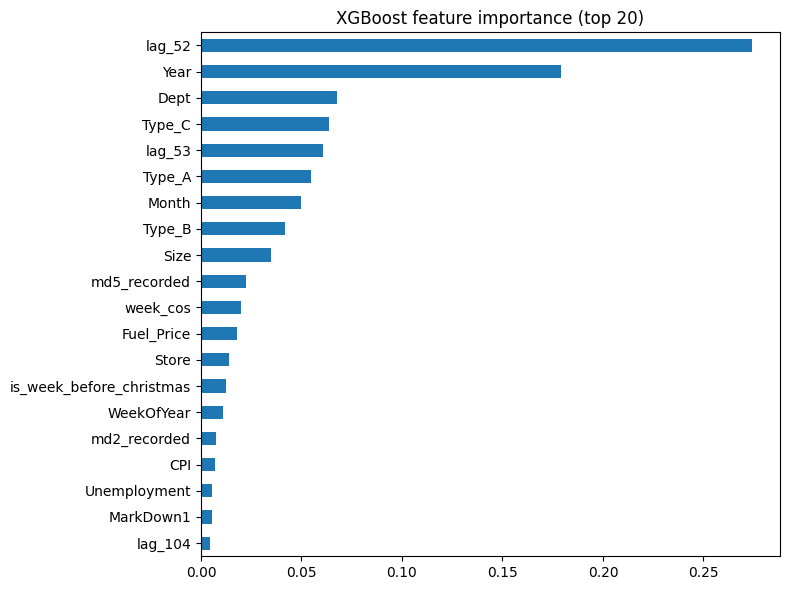

In [12]:
# which features actually carry the model
import matplotlib.pyplot as plt
m = final_pipe.named_steps["model"]
reg = m.regressor_ if hasattr(m, "regressor_") else m
imp = pd.Series(reg.feature_importances_, index=reg.feature_names_in_).nlargest(20)
fig, ax = plt.subplots(figsize=(8, 6))
imp.iloc[::-1].plot.barh(ax=ax)
ax.set_title("XGBoost feature importance (top 20)")
plt.tight_layout(); plt.show()

The main result here is the gap between baseline_lags and submission_lags: short lags look
great during training but are missing at forecast time, so the model that leans on them
collapses. The log target and the tuning only add a little on top of that. The pipeline saved
in the final run is our candidate from this notebook.